In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## first look at correlation between activity and expression

In [11]:
psi_response = pd.read_csv('data/psi_response.csv')
psi_response['event_type'] = np.where(psi_response['event_id'].str.contains(';AR:'), 'AR', 'SE')
psi_response_single_gene = psi_response.drop_duplicates(subset=['gene_id'], keep='first')
psi_response_single_gene

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi,event_type
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831,SE
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808,SE
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052,SE
7,ENSG00000157870;SE:chr1:2588453-2588550:258862...,ENSG00000157870,0.133539,0.507856,0.133539,0.507856,0.737987,0.721811,1.000000,1.000000,SE
8,ENSG00000158109;SE:chr1:3625515-3625713:362588...,ENSG00000158109,0.920123,0.967080,0.920123,0.945961,0.920123,0.967080,1.000000,0.952017,SE
...,...,...,...,...,...,...,...,...,...,...,...
24941,ENSG00000259075;AR:chr12:89524440-89525120:895...,ENSG00000259075,-0.508638,-0.366532,-1.000000,-1.000000,-0.337242,-0.229148,1.000000,1.000000,AR
24942,ENSG00000259112;AR:chr11:78017270-78072998:780...,ENSG00000259112,-0.721246,0.729974,-1.000000,-1.000000,-0.721246,0.738781,1.000000,1.000000,AR
24943,ENSG00000259207;AR:chr17:47253940-47274419:472...,ENSG00000259207,0.201397,1.089905,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000,AR
24949,ENSG00000259305;AR:chr8:123231757-123237798:12...,ENSG00000259305,0.733197,0.445604,-1.000000,-1.000000,0.744293,0.460898,1.000000,1.000000,AR


In [12]:
promoter_df = pd.read_csv('data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/GeneList.txt', sep='\t', index_col='symbol')
promoter_df['PromoterActivity'] = np.sqrt(promoter_df['H3K27ac.RPM.TSS1Kb']*promoter_df['DHS.RPM.TSS1Kb'])
promoter_df

,chr,start,end,name,score,strand,tss,Expression,cellType,H3K27ac.ENCFF600THN.bam.readCount,...,DHS.ENCFF257HEE.bam.readCount.quantile.TSS1Kb,DHS.ENCFF257HEE.bam.RPM.quantile.TSS1Kb,DHS.ENCFF257HEE.bam.RPKM.TSS1Kb,DHS.ENCFF257HEE.bam.RPKM.quantile.TSS1Kb,DHS.RPM.TSS1Kb,DHS.RPM.quantile.TSS1Kb,DHS.RPKM.TSS1Kb,DHS.RPKM.quantile.TSS1Kb,PromoterActivityQuantile,PromoterActivity
symbol,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,chrX,100625428,100636750,ENSG00000000003,0,-,100636750,NaN,K562,13,...,0.222207,0.222207,0.600308,0.222207,0.600308,0.222207,0.600308,0.222207,0.248245,0.340655
ENSG00000000005,chrX,100584935,100600019,ENSG00000000005,0,+,100584935,NaN,K562,21,...,0.043995,0.043995,0.176740,0.043995,0.176740,0.043995,0.176740,0.043995,0.039805,0.124578
ENSG00000000419,chr20,50934842,50958531,ENSG00000000419,0,-,50958531,NaN,K562,303,...,0.597785,0.597785,6.850214,0.597785,6.850214,0.597785,6.850214,0.597785,0.791478,12.474358
ENSG00000000457,chr1,169849258,169893895,ENSG00000000457,0,-,169893895,NaN,K562,290,...,0.950482,0.950482,20.270295,0.950482,20.270295,0.950482,20.270295,0.950482,0.993198,23.672386
ENSG00000000460,chr1,169795044,169987021,ENSG00000000460,0,+,169795044,NaN,K562,1158,...,0.729281,0.729281,9.900509,0.729281,9.900509,0.729281,9.900509,0.729281,0.887849,14.209941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000259399,chr20,36574515,36612347,ENSG00000259399,0,+,36574515,NaN,K562,548,...,0.531779,0.531779,5.366204,0.531779,5.366204,0.531779,5.366204,0.531779,0.559776,5.576129
ENSG00000259431,chr14,23556270,23560535,ENSG00000259431,0,+,23556270,NaN,K562,94,...,0.568428,0.568428,6.201150,0.568428,6.201150,0.568428,6.201150,0.568428,0.602275,6.462903
ENSG00000259511,chr15,84172490,84182235,ENSG00000259511,0,+,84172490,NaN,K562,15,...,0.169995,0.169995,0.466229,0.169995,0.466229,0.169995,0.466229,0.169995,0.288186,0.460002


In [13]:
# merge PromoterActivity with psi_response
psi_response_single_gene = psi_response_single_gene.merge(promoter_df[['PromoterActivity']], left_on='gene_id', right_index=True, how='left')
psi_response_single_gene

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi,event_type,PromoterActivity
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831,SE,11.253588
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808,SE,9.454072
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052,SE,19.078763
7,ENSG00000157870;SE:chr1:2588453-2588550:258862...,ENSG00000157870,0.133539,0.507856,0.133539,0.507856,0.737987,0.721811,1.000000,1.000000,SE,10.641283
8,ENSG00000158109;SE:chr1:3625515-3625713:362588...,ENSG00000158109,0.920123,0.967080,0.920123,0.945961,0.920123,0.967080,1.000000,0.952017,SE,5.379630
...,...,...,...,...,...,...,...,...,...,...,...,...
24941,ENSG00000259075;AR:chr12:89524440-89525120:895...,ENSG00000259075,-0.508638,-0.366532,-1.000000,-1.000000,-0.337242,-0.229148,1.000000,1.000000,AR,8.770833
24942,ENSG00000259112;AR:chr11:78017270-78072998:780...,ENSG00000259112,-0.721246,0.729974,-1.000000,-1.000000,-0.721246,0.738781,1.000000,1.000000,AR,8.034203
24943,ENSG00000259207;AR:chr17:47253940-47274419:472...,ENSG00000259207,0.201397,1.089905,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000,AR,2.164354
24949,ENSG00000259305;AR:chr8:123231757-123237798:12...,ENSG00000259305,0.733197,0.445604,-1.000000,-1.000000,0.744293,0.460898,1.000000,1.000000,AR,0.395037


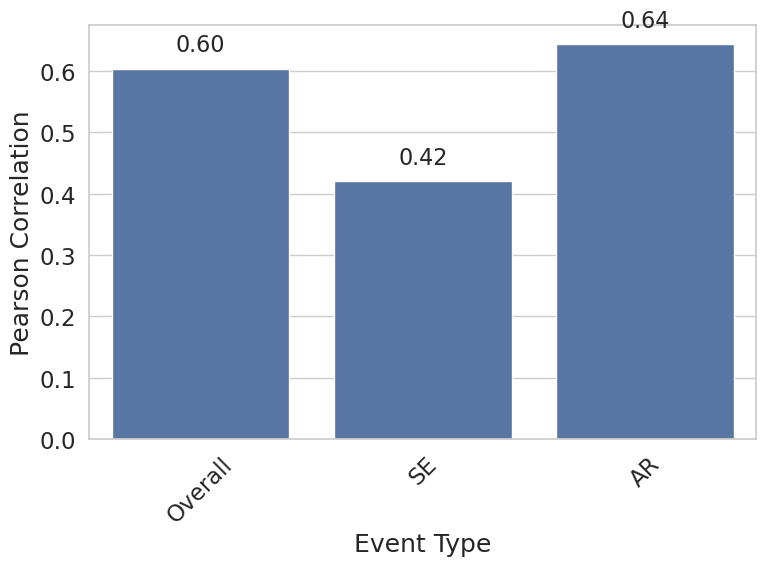

In [14]:
# calculate correlation between PromoterActivity and K562_gene_level_tpm

correlation_overall = psi_response_single_gene[['PromoterActivity', 'K562_gene_level_tpm']].corr(method='pearson').iloc[0, 1]
correlation_se = psi_response_single_gene[psi_response_single_gene['event_type'] == 'SE'][['PromoterActivity', 'K562_gene_level_tpm']].corr(method='pearson').iloc[0, 1]
correlation_ar = psi_response_single_gene[psi_response_single_gene['event_type'] == 'AR'][['PromoterActivity', 'K562_gene_level_tpm']].corr(method='pearson').iloc[0, 1]

# bar plot of correlations
sns.set(style='whitegrid', font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=['Overall', 'SE', 'AR'], y=[correlation_overall, correlation_se, correlation_ar], ax=ax)
for i, v in enumerate([correlation_overall, correlation_se, correlation_ar]):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=16)
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Event Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Check expression of AR events vs ES events

In [15]:
ar_events = psi_response[psi_response['event_type'] == 'AR']
es_events = psi_response[psi_response['event_type'] == 'SE']

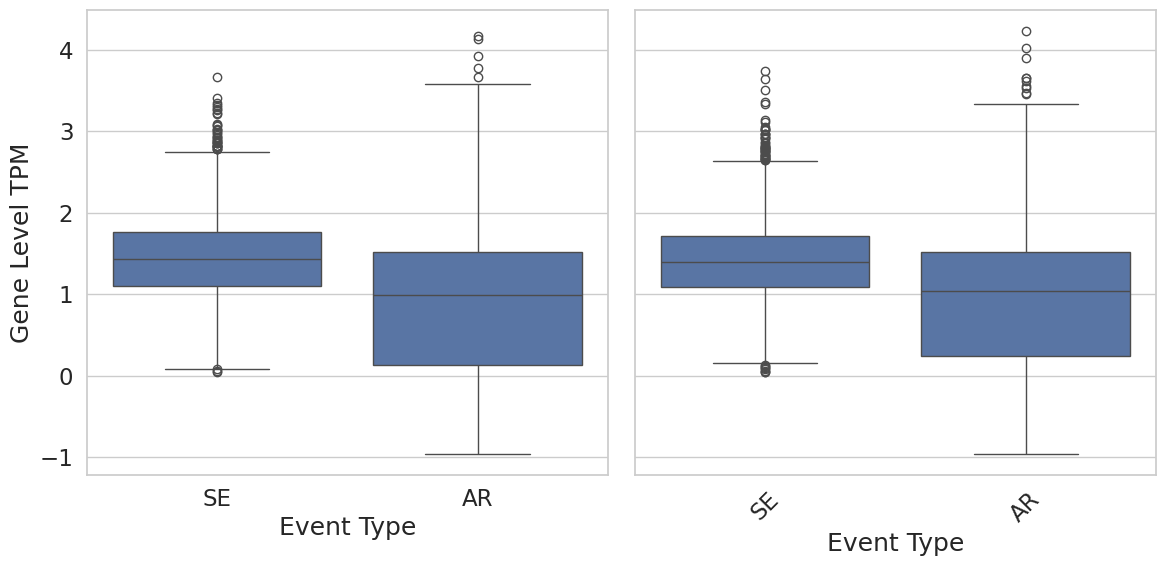

In [16]:
sns.set(style='whitegrid', font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 6), nrows=1, ncols=2, sharey=True)
sns.boxplot(x='event_type', y='K562_gene_level_tpm', data=psi_response_single_gene, ax=ax[0])
sns.boxplot(x='event_type', y='GM12878_gene_level_tpm', data=psi_response_single_gene, ax=ax[1])
ax[0].set_ylabel('Gene Level TPM')
ax[0].set_xlabel('Event Type')
ax[1].set_xlabel('Event Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## check free params of our models

In [23]:
from torch import nn

def print_num_params(model):
    total = 0
    print("Parameter counts by submodule:\n")
    for name, module in model.named_modules():
        if isinstance(module, nn.Sequential):
            num_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
            total += num_params
            print(f"{name:30} -> {num_params:,} trainable params")
    print(f"\nTotal trainable parameters: {total:,}")

In [25]:
from EPInformer.models_multi import EPInformer_v2, seq_256bp_encoder, seq_256bp_encoder_small
from EPInformer.models import EPInformer_v2 as EPInformer_v2_old

epinformer = EPInformer_v2(n_encoder=4, pre_trained_encoder="None", n_enhancer=60, 
                              out_dim=64, n_extraFeat=3, device='cpu', exon_data=True, 
                              separate_attention=True)
# check free params of our models
print_num_params(epinformer)

Parameter counts by submodule:

event_encoder.stem_conv        -> 8,448 trainable params
event_encoder.conv_tower.0.0   -> 49,344 trainable params
event_encoder.conv_tower.0.1   -> 4,160 trainable params
event_encoder.conv_tower.1.0   -> 24,960 trainable params
event_encoder.conv_tower.1.1   -> 16,512 trainable params
attn_encoder.0.ff              -> 33,088 trainable params
attn_encoder.1.ff              -> 33,088 trainable params
attn_encoder.2.ff              -> 33,088 trainable params
attn_encoder.3.ff              -> 33,088 trainable params
conv_out                       -> 52,076 trainable params
event_conv_out                 -> 51,954 trainable params
pToExpr                        -> 26,113 trainable params
pToSpliceBinary                -> 9,601 trainable params
pToSplice                      -> 26,113 trainable params
add_pos_conv                   -> 8,512 trainable params

Total trainable parameters: 410,145
